In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("fake_job_dashboard_data.csv")

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,country,text
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,US,"Marketing Intern Food52, a fast-growing, James..."
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,NZ,Customer Service - Cloud Video Production Orga...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,US,Commissioning Machinery Assistant (CMA) Our cl...
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,US,Account Executive - Washington DC THE COMPANY:...
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,US,Bill Review Manager JOB TITLE: Itemization Rev...


In [4]:
df.shape

(17880, 20)

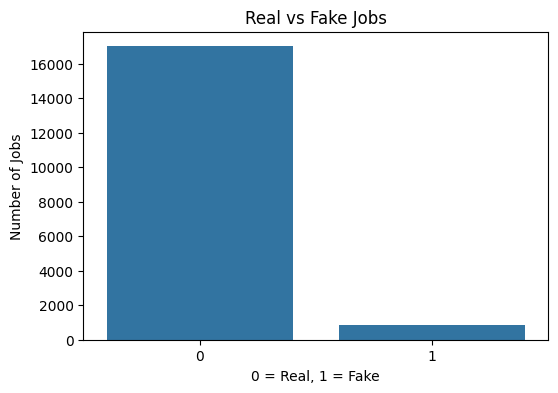

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='fraudulent', data=df)

plt.title('Real vs Fake Jobs')
plt.xlabel('0 = Real, 1 = Fake')
plt.ylabel('Number of Jobs')

plt.show()

In [6]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'country', 'text'],
      dtype='str')

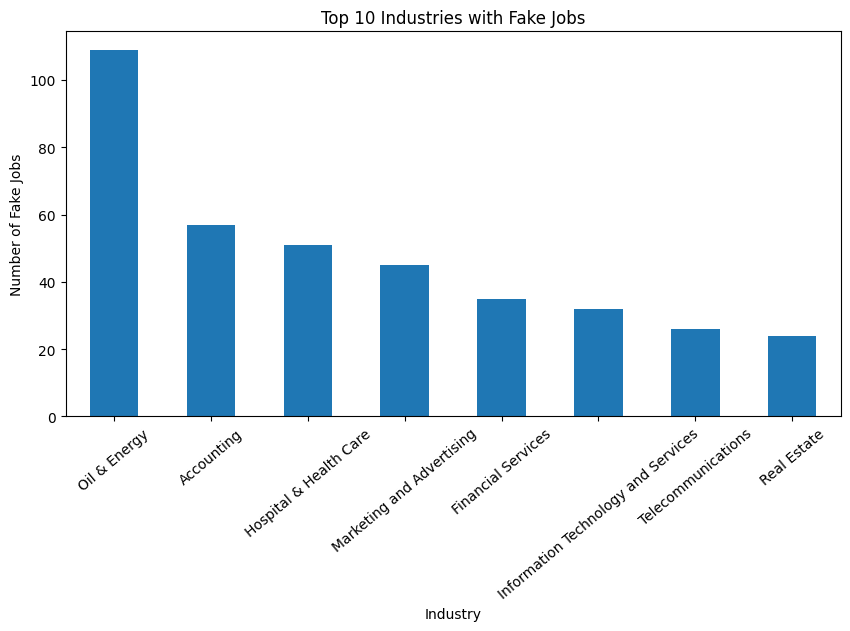

In [15]:
fake_jobs = df[df['fraudulent'] == 1]

plt.figure(figsize=(10,5))

fake_jobs['industry'].value_counts().head(8).plot(
    kind='bar'
)

plt.title('Top 10 Industries with Fake Jobs')
plt.xlabel('Industry')
plt.ylabel('Number of Fake Jobs')

plt.xticks(rotation=40)

plt.savefig("top_fake_industries.png", bbox_inches="tight")

plt.show()

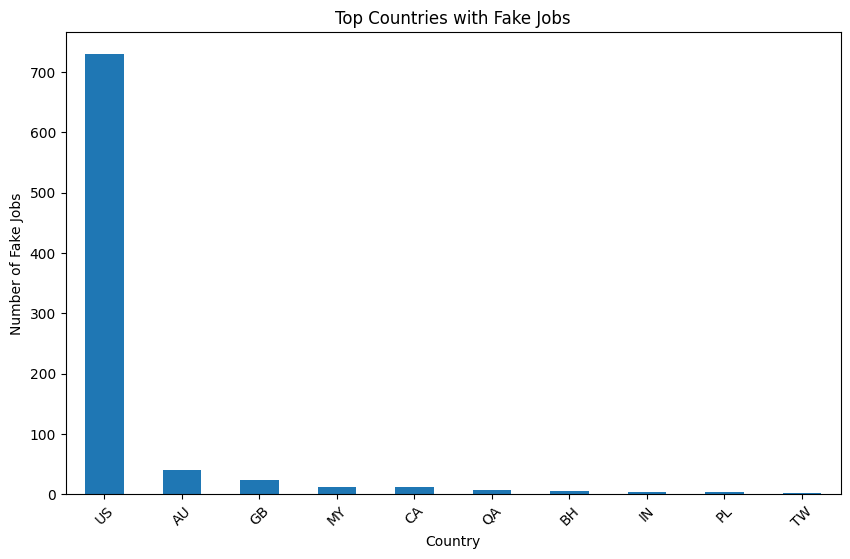

In [8]:
plt.figure(figsize=(10,6))

fake_jobs['country'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Top Countries with Fake Jobs')
plt.xlabel('Country')
plt.ylabel('Number of Fake Jobs')

plt.xticks(rotation=45)

plt.savefig("top_fake_countries.png", bbox_inches="tight")

plt.show()

In [18]:
fake_jobs['description'] = fake_jobs['description'].fillna('').astype(str)

In [19]:
text = " ".join(fake_jobs['description'])

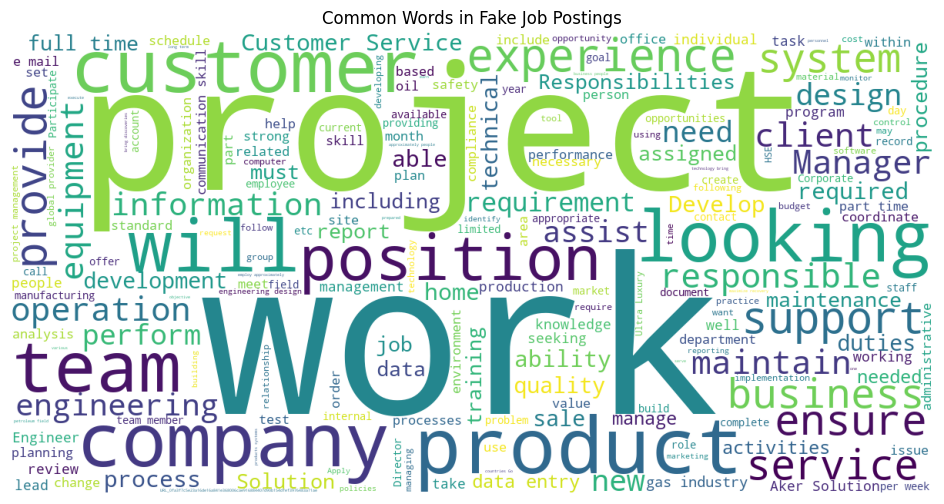

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_jobs['description'] = fake_jobs['description'].fillna('').astype(str)

text = " ".join(fake_jobs['description'])

wc = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Common Words in Fake Job Postings")

plt.savefig(
    "wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = TfidfVectorizer(
    stop_words='english',
    max_features=5000
).fit_transform(df['text'].fillna(''))

y = df['fraudulent']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

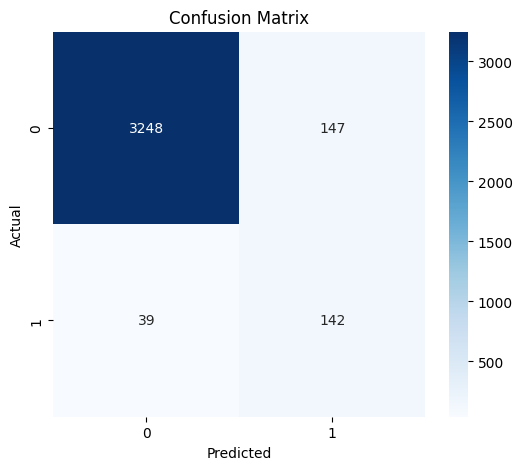

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3395
           1       0.49      0.78      0.60       181

    accuracy                           0.95      3576
   macro avg       0.74      0.87      0.79      3576
weighted avg       0.96      0.95      0.95      3576



In [31]:
report = classification_report(
    y_test,
    predictions
)

with open(
    "classification_report.txt",
    "w"
) as f:
    f.write(report)